In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as lr 

## Data:
In this document we only work with one binary target variabel called "Complication". Complication == 1 if a patient have 1 or more complications

In [3]:
path = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\raw\synthetic_dataset_A_non-iid.csv"
df = pd.read_csv(path)
df["Complication"] = ((df["Risk_AlveolarOsteitis"] == 0) & 
                    (df["Risk_SecondaryInfection"] == 0) & 
                    (df["Risk_NerveDysesthesia"] == 0) & 
                    (df["Risk_Bleeding"] == 0)).astype(int)

# Vi standardisere vores features.
variables = df.columns[1:27].tolist()
scaler = StandardScaler()
df[variables] = scaler.fit_transform(df[variables])

## Funktions:

In [10]:
def multiple_regression(df, variables):
    '''
    Input: df (dataframe), variables (all the variables you want to include in the regression as a list)
    Returns: (intercept, [list of coefficients])
    '''
    n = len(df)
    d = len(variables)

    # construct empty design matrix
    X = np.zeros((n, d))

    # targets
    y = df["Complication"]

    # fill out design matrix 
    for i in range(d):
        X[:, i] = df[variables[i]]
    #make model
    model = lr()
    #fit model
    model.fit(X,  y)
    return model.intercept_, model.coef_


# function that plots the absolute values of the coefficients
def plot_magnitude(coefs, variable_names, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    magnitudes = np.abs(coefs)
    
    ax.bar(range(len(coefs)), magnitudes)
    
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(variable_names, rotation=90)
    
    ax.set_title(title)
    ax.set_xlabel("Variables")
    ax.set_ylabel("|Coefficient|")
    
    plt.tight_layout()
    plt.show()

# Federted multibel regression funktion:
def FL_mul_reg(df, variables, num_clients, weighted = True):
    d = len(variables)
    k = num_clients
    n = len(df)
    all_coefs = np.zeros((k, d+2))
    for i in range(1, num_clients+1):
        client_data = df[df["Client"] == i]
        if len(client_data) > 0:
            inter, coefs = multiple_regression(client_data, variables)
            all_coefs[i-1, 0] = inter
            all_coefs[i-1, 1] = len(client_data)
            all_coefs[i-1, 2:] = coefs

    # vægtet gennemsnit
    if weighted:
        means_intercept = 0
        means_coefs = np.zeros(d)
        for i in range(k):
            means_intercept += all_coefs[i, 1] * all_coefs[i, 0]
        means_intercept /= n
        for i in range(d):
            for j in range(k):
                means_coefs[i] += all_coefs[j, 1] * all_coefs[j, i+2]
            means_coefs[i] /= n

    # det simple ikke-vægtede gennemsnit
    if not weighted:
        means_intercept = np.mean(all_coefs[:, 0])
        means_coefs = np.mean(all_coefs[:, 2:], axis=0)

    return means_intercept, means_coefs

## Results:

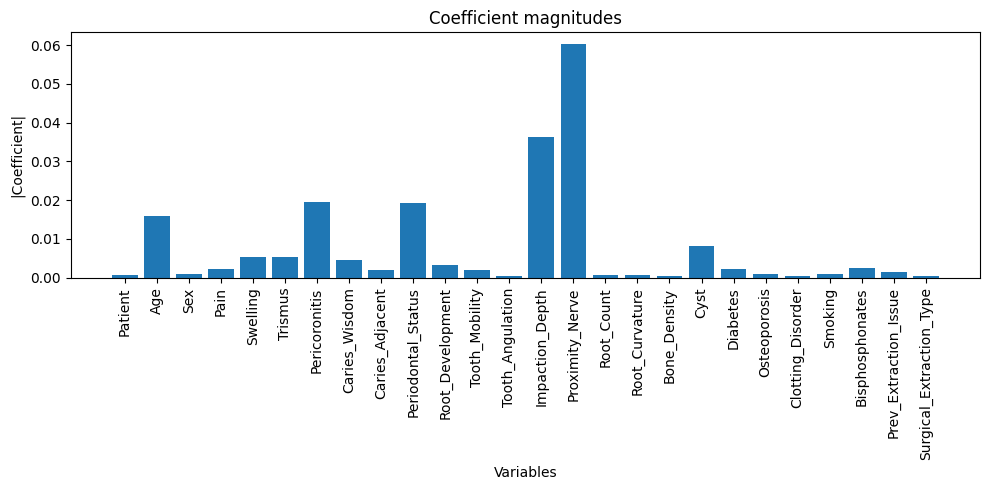

In [ ]:
# Centralized multibel regression:
inter, coef = multiple_regression(df, variables)
plot_magnitude(coef, variables, title=f"Coefficient magnitudes")

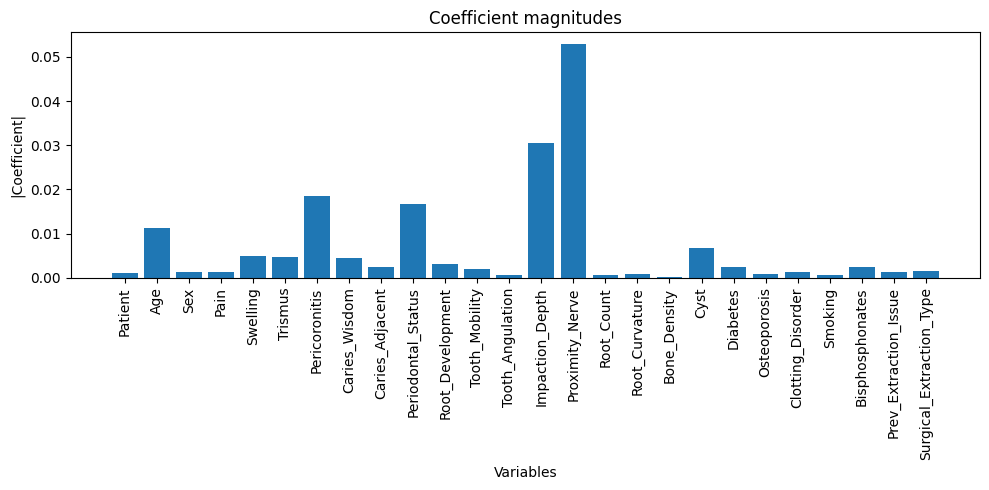

In [ ]:
# Federated multibel regression
co = FL_mul_reg(df, variables, 10)
coefs = co[1]
plot_magnitude(coefs, variables, title=f"Coefficient magnitudes")